<a href="https://colab.research.google.com/github/alkrkhey5-source/Cartpole-DQN/blob/main/Another_copy_of_another_copy_of_untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ بدأ التشغيل
شكل البيانات: (60000, 28, 28, 1)
عدد الفئات: 7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        21,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,847 (85.34 KB)

 Trainable params: 21,847 (85.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8742 - loss: 0.4168 - val_accuracy: 0.9425 - val_loss: 0.1982
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9506 - loss: 0.1669 - val_accuracy: 0.9609 - val_loss: 0.1364
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9624 - loss: 0.1245 - val_accuracy: 0.9676 - val_loss: 0.1126
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

✅ F1-score: 0.9662
✅ Accuracy: 0.9662


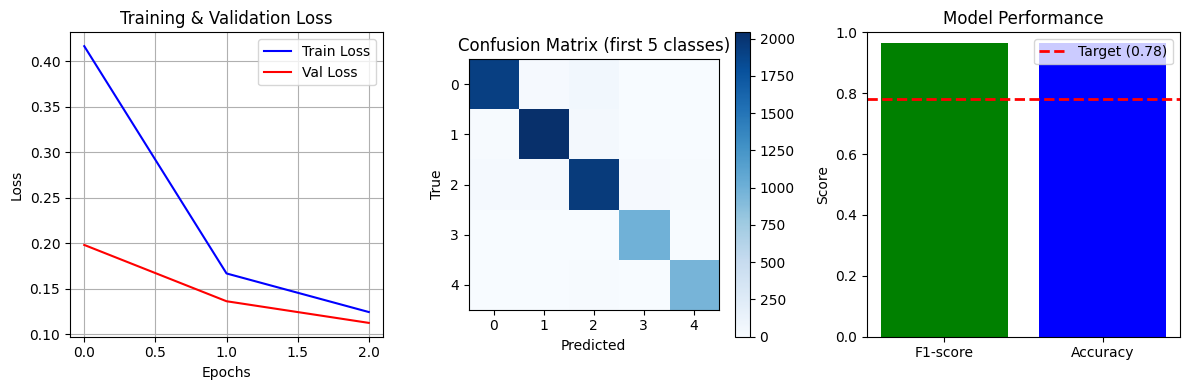


✅ تم حفظ المخططات في ملف results.png


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix

print("✅ بدأ التشغيل")

# 1. تحميل بيانات MNIST (أرقام مكتوبة بخط اليد)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. تطبيع الصور (0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. جعل الفئات 7 فقط (بدل 10)
y_train = y_train % 7
y_test = y_test % 7

# 4. إضافة بُعد القنوات (لجعلها 28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"شكل البيانات: {x_train.shape}")
print(f"عدد الفئات: {len(np.unique(y_train))}")

# 5. بناء نموذج بسيط جداً
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(8, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 6. تدريب (epochs قليلة جداً)
history = model.fit(x_train, y_train, validation_split=0.2, epochs=3, batch_size=64, verbose=1)

# 7. التقييم
y_pred = np.argmax(model.predict(x_test), axis=1)
f1 = f1_score(y_test, y_pred, average='weighted')
acc = np.mean(y_pred == y_test)

print(f"\n✅ F1-score: {f1:.4f}")
print(f"✅ Accuracy: {acc:.4f}")

# 8. رسم النتائج
plt.figure(figsize=(12,4))

# منحنى الخسارة
plt.subplot(1,3,1)
plt.plot(history.history['loss'], 'b-', label='Train Loss')
plt.plot(history.history['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)

# مصفوفة الارتباك (أول 5 فئات فقط)
plt.subplot(1,3,2)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm[:5,:5], cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix (first 5 classes)')
plt.xlabel('Predicted')
plt.ylabel('True')

# المقاييس
plt.subplot(1,3,3)
colors = ['blue' if val < 0.78 else 'green' for val in [f1, acc]]
plt.bar(['F1-score', 'Accuracy'], [f1, acc], color=['green', 'blue'])
plt.axhline(y=0.78, color='red', linestyle='--', linewidth=2, label='Target (0.78)')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance')
plt.legend()

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

print("\n✅ تم حفظ المخططات في ملف results.png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')